In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import shap
shap.initjs()


warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight

print("All dependencies loaded successfully!")

All dependencies loaded successfully!


In [2]:
df = pd.read_csv('../dataset/cleaned_data_with_risk.csv')
df.head()

,Age,Gender,University,Department,Academic_Year,CGPA,Scholarship,A1_Nervous,A2_Worrying,A3_Relaxing,...,D3_SleepTrouble,D4_Tired,D5_Appetite,D6_Failure,D7_Concentration,D8_Psychomotor,D9_SuicidalThoughts,Depression_Score,Depression_Label,Risk_Level
0,18-22,Female,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,...,1,1,2,1,1,1,1,11,Moderate Depression,Moderate Risk
1,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.80 - 4.00,No,2,2,1,...,1,1,1,1,1,1,1,9,Mild Depression,Moderate Risk
2,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.00 - 3.39,No,2,1,1,...,2,3,2,2,2,2,1,16,Moderately Severe Depression,High Risk
3,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,2,1,1,...,1,1,1,1,1,1,1,9,Mild Depression,Moderate Risk
4,18-22,Male,"Independent University, Bangladesh (IUB)",Engineering - CS / CSE / CSC / Similar to CS,First Year or Equivalent,3.40 - 3.79,No,1,1,1,...,1,1,1,1,1,1,1,9,Mild Depression,Moderate Risk


In [3]:
print(df['Risk_Level'].isnull().sum())

44


In [4]:
df = df.dropna(subset=['Risk_Level'])

In [5]:
regression_target = ['Anxiety_Score', 'Stress_Score', 'Depression_Score']
classification_target = ['Anxiety_Label', 'Stress_Label', 'Depression_Label','Risk_Level']
feature_cols = [col for col in df.columns if col not in regression_target + classification_target]

In [6]:
print('Gender distribution before removal:')
gender_counts = df['Gender'].value_counts()
print(gender_counts)
df_cleaned = df[df['Gender'] != 'Prefer not to say'].copy()
df = df_cleaned
print(df['Gender'].value_counts())

Gender distribution before removal:
Gender
Male                 1334
Female                589
Prefer not to say      10
Name: count, dtype: int64
Gender
Male      1334
Female     589
Name: count, dtype: int64


In [7]:
ordinal_features = ['Age', 'Academic_Year', 'CGPA']
binary_features = ['Gender', 'Scholarship']

In [8]:
ordinal_encoder = OrdinalEncoder()
df[ordinal_features] = ordinal_encoder.fit_transform(df[ordinal_features])

In [9]:
# Binary mapping
binary_map = {
    'Gender': {'Male': 1, 'Female': 0},
    'Scholarship': {'Yes': 1, 'No': 0}
}

for feature, mapping in binary_map.items():
    df[feature] = df[feature].map(mapping)

In [10]:
#lable encoding of University and Department
label_encoder = LabelEncoder()

for feature in ['University', 'Department']:
    df[feature] = label_encoder.fit_transform(df[feature])

In [11]:
X = df[feature_cols]
X_train , X_test = train_test_split(X, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## regression models

### Linear and logistic and random forest Regression for Anxiety, Stress and Depression score

In [12]:
y_anxiety = df['Anxiety_Score']
y_stress = df['Stress_Score']
y_depression = df['Depression_Score']

y_anxiety_train, y_anxiety_test = train_test_split(y_anxiety, test_size=0.2, random_state=42)
y_stress_train, y_stress_test = train_test_split(y_stress, test_size=0.2, random_state=42)
y_depression_train, y_depression_test = train_test_split(y_depression, test_size=0.2, random_state=42)

In [13]:
# anxiety score models
anxiety_model_linreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

anxiety_model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression())
])

anxiety_model_rforest = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

anxiety_model_linreg.fit(X_train, y_anxiety_train)

anxiety_model_logreg.fit(X_train, y_anxiety_train)

anxiety_model_rforest.fit(X_train, y_anxiety_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [14]:
#anxiety models evaluation
y_anxiety_pred_linreg = anxiety_model_linreg.predict(X_test)
y_anxiety_pred_logreg = anxiety_model_logreg.predict(X_test)
y_anxiety_pred_rforest = anxiety_model_rforest.predict(X_test)

print("Linear Regression:")
print("  MAE:", mean_absolute_error(y_anxiety_test, y_anxiety_pred_linreg))
print("  RMSE:", np.sqrt(mean_squared_error(y_anxiety_test, y_anxiety_pred_linreg)))
print("  R2:", r2_score(y_anxiety_test, y_anxiety_pred_linreg))

print("\nLogistic Regression:")
print("  MAE:", mean_absolute_error(y_anxiety_test, y_anxiety_pred_logreg))
print("  RMSE:", np.sqrt(mean_squared_error(y_anxiety_test, y_anxiety_pred_linreg)))
print("  R2:", r2_score(y_anxiety_test, y_anxiety_pred_logreg))

print("\nRandom Forest:")
print("  MAE:", mean_absolute_error(y_anxiety_test, y_anxiety_pred_rforest))
print("  RMSE:", np.sqrt(mean_squared_error(y_anxiety_test, y_anxiety_pred_rforest)))
print("  R2:", r2_score(y_anxiety_test, y_anxiety_pred_rforest))

Linear Regression:
  MAE: 8.699534599192655e-15
  RMSE: 1.0722445719853791e-14
  R2: 1.0

Logistic Regression:
  MAE: 0.7298701298701299
  RMSE: 1.0722445719853791e-14
  R2: 0.9576328927471159

Random Forest:
  MAE: 0.4982207792207793
  RMSE: 0.7506068973075817
  R2: 0.9795323348965852


In [15]:
#saving the best model to model directory
joblib.dump(anxiety_model_rforest, '../models/anxiety_score_model_rforest.pkl')

['../models/anxiety_score_model_rforest.pkl']

In [16]:
# stress score models
stress_model_linreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

stress_model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression())
])

stress_model_rforest = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

stress_model_linreg.fit(X_train, y_stress_train)

stress_model_logreg.fit(X_train, y_stress_train)

stress_model_rforest.fit(X_train, y_stress_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [17]:
#stress models evaluation
y_stress_pred_linreg = stress_model_linreg.predict(X_test)
y_stress_pred_logreg = stress_model_logreg.predict(X_test)
y_stress_pred_rforest = stress_model_rforest.predict(X_test)

print("Linear Regression:")
print("  MAE:", mean_absolute_error(y_stress_test, y_stress_pred_linreg))
print("  RMSE:", np.sqrt(mean_squared_error(y_stress_test, y_stress_pred_linreg)))
print("  R2:", r2_score(y_stress_test, y_stress_pred_linreg))

print("\nLogistic Regression:")
print("  MAE:", mean_absolute_error(y_stress_test, y_stress_pred_logreg))
print("  RMSE:", np.sqrt(mean_squared_error(y_stress_test, y_stress_pred_logreg)))
print("  R2:", r2_score(y_stress_test, y_stress_pred_logreg))

print("\nRandom Forest:")
print("  MAE:", mean_absolute_error(y_stress_test, y_stress_pred_rforest))
print("  RMSE:", np.sqrt(mean_squared_error(y_stress_test, y_stress_pred_rforest)))
print("  R2:", r2_score(y_stress_test, y_stress_pred_rforest))

Linear Regression:
  MAE: 1.8474111129762605e-14
  RMSE: 2.2580675483807713e-14
  R2: 1.0

Logistic Regression:
  MAE: 1.4961038961038962
  RMSE: 2.1514114968019085
  R2: 0.905659910350307

Random Forest:
  MAE: 1.1247662337662336
  RMSE: 1.5602584909051316
  R2: 0.9503816379391902


In [18]:
#saving the best model to model directory
joblib.dump(stress_model_rforest, '../models/stress_score_model_rforest.pkl')

['../models/stress_score_model_rforest.pkl']

In [19]:
# depression score models
depression_model_linreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

depression_model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression())
])

depression_model_rforest = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

depression_model_linreg.fit(X_train, y_depression_train)

depression_model_logreg.fit(X_train, y_depression_train)

depression_model_rforest.fit(X_train, y_depression_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


In [20]:
#depression models evaluation
y_depression_pred_linreg = depression_model_linreg.predict(X_test)
y_depression_pred_logreg = depression_model_logreg.predict(X_test)
y_depression_pred_rforest = depression_model_rforest.predict(X_test)

print("Linear Regression:")
print("  MAE:", mean_absolute_error(y_depression_test, y_depression_pred_linreg))
print("  RMSE:", np.sqrt(mean_squared_error(y_depression_test, y_depression_pred_linreg)))
print("  R2:", r2_score(y_depression_test, y_depression_pred_linreg))

print("\nLogistic Regression:")
print("  MAE:", mean_absolute_error(y_depression_test, y_depression_pred_logreg))
print("  RMSE:", np.sqrt(mean_squared_error(y_depression_test, y_depression_pred_logreg)))
print("  R2:", r2_score(y_depression_test, y_depression_pred_logreg))

print("\nRandom Forest:")
print("  MAE:", mean_absolute_error(y_depression_test, y_depression_pred_rforest))
print("  RMSE:", np.sqrt(mean_squared_error(y_depression_test, y_depression_pred_rforest)))
print("  R2:", r2_score(y_depression_test, y_depression_pred_rforest))

Linear Regression:
  MAE: 6.3210619999437485e-15
  RMSE: 8.073818652471105e-15
  R2: 1.0

Logistic Regression:
  MAE: 1.0285714285714285
  RMSE: 1.3975860450243316
  R2: 0.9525508195603641

Random Forest:
  MAE: 0.8075584415584415
  RMSE: 1.1008451298888504
  R2: 0.9705609320931953


In [21]:
#saving the best model to model directory
joblib.dump(depression_model_rforest, '../models/depression_score_model_rforest.pkl')

['../models/depression_score_model_rforest.pkl']

## classification models

### Logistic regression, random forest for Anxiety, Stress and Depression label and risk level

In [22]:
y_anxiety_label = df['Anxiety_Label']
y_stress_label = df['Stress_Label']
y_depression_label = df['Depression_Label']
y_risk_label = df['Risk_Level']

y_anxiety_label_train, y_anxiety_label_test = train_test_split(y_anxiety_label, test_size=0.2, random_state=42)
y_stress_label_train, y_stress_label_test = train_test_split(y_stress_label, test_size=0.2, random_state=42)
y_depression_label_train, y_depression_label_test = train_test_split(y_depression_label, test_size=0.2, random_state=42)
y_risk_label_train, y_risk_label_test = train_test_split(y_risk_label, test_size=0.2, random_state=42)

In [23]:
# anxiety label models
anxiety_label_model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

anxiety_label_model_rforest = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

anxiety_label_model_logreg.fit(X_train, y_anxiety_label_train)

anxiety_label_model_rforest.fit(X_train, y_anxiety_label_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5


In [24]:
#anxiety label models evaluation
y_anxiety_label_pred_logreg = anxiety_label_model_logreg.predict(X_test)
y_anxiety_label_pred_rforest = anxiety_label_model_rforest.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_anxiety_label_test, y_anxiety_label_pred_logreg))

print("\nRandom Forest:")
print(classification_report(y_anxiety_label_test, y_anxiety_label_pred_rforest))


Logistic Regression:
                  precision    recall  f1-score   support

    Mild Anxiety       0.98      0.96      0.97        99
 Minimal Anxiety       0.92      0.96      0.94        24
Moderate Anxiety       0.95      0.99      0.97       128
  Severe Anxiety       1.00      0.97      0.98       134

        accuracy                           0.97       385
       macro avg       0.96      0.97      0.97       385
    weighted avg       0.97      0.97      0.97       385


Random Forest:
                  precision    recall  f1-score   support

    Mild Anxiety       0.90      0.91      0.90        99
 Minimal Anxiety       0.95      0.79      0.86        24
Moderate Anxiety       0.88      0.90      0.89       128
  Severe Anxiety       0.94      0.95      0.94       134

        accuracy                           0.91       385
       macro avg       0.92      0.89      0.90       385
    weighted avg       0.91      0.91      0.91       385



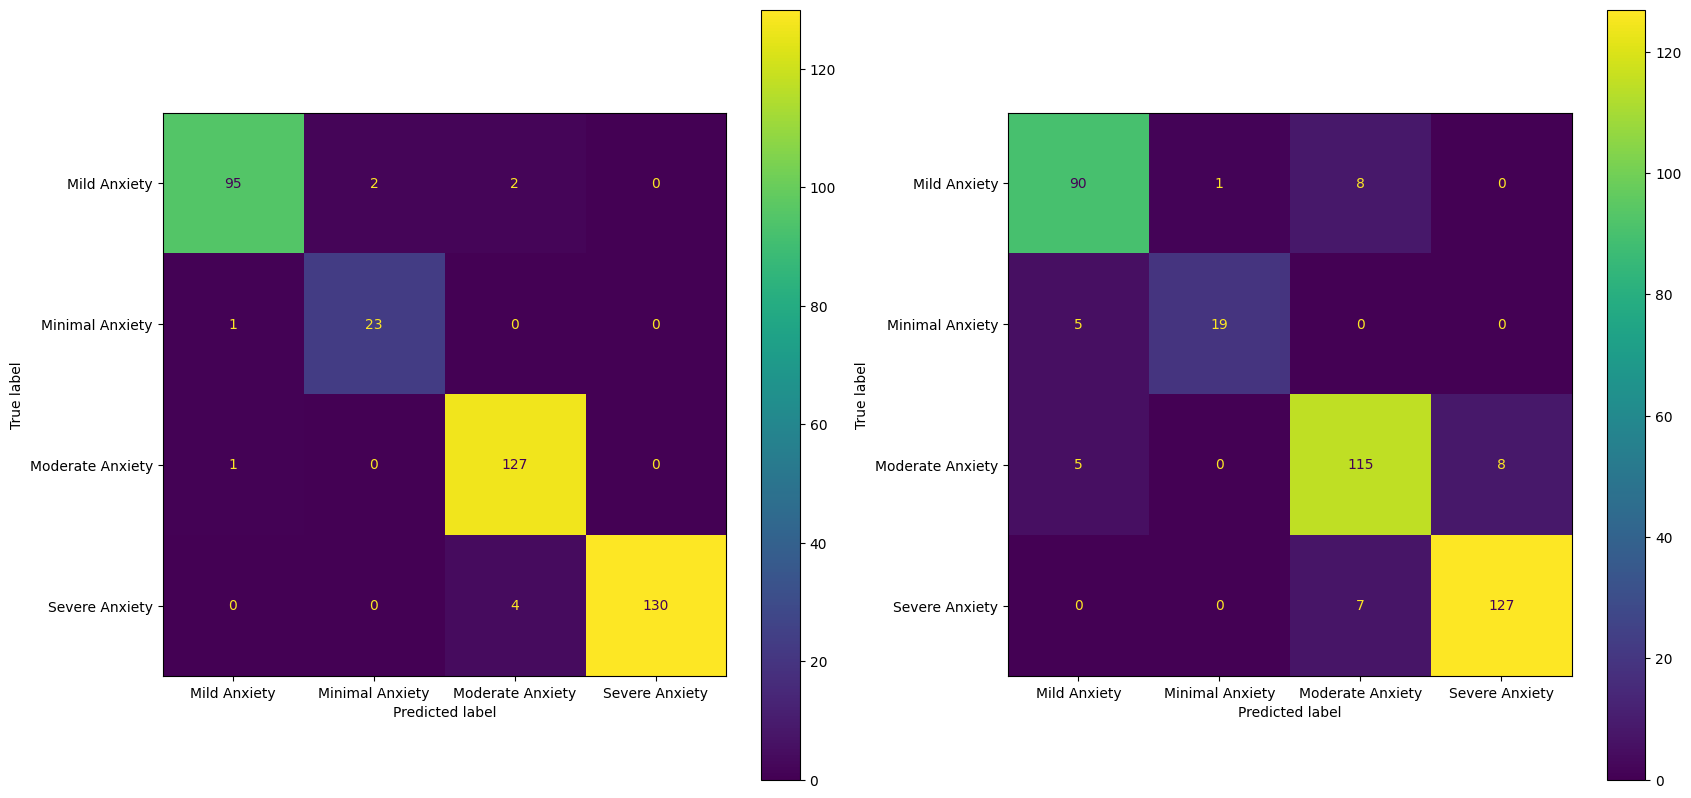

In [25]:
# confusion matrix
fig, ax = plt.subplots(1,2,figsize=(20, 10))
ConfusionMatrixDisplay.from_estimator(anxiety_label_model_logreg, X_test, y_anxiety_label_test, ax=ax[0])
ConfusionMatrixDisplay.from_estimator(anxiety_label_model_rforest, X_test, y_anxiety_label_test, ax=ax[1])
plt.show()


In [26]:
#saving the best model to model directory
joblib.dump(anxiety_label_model_rforest, '../models/anxiety_label_model_rforest.pkl')

['../models/anxiety_label_model_rforest.pkl']

In [27]:
# stress label models
stress_label_model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

stress_label_model_rforest = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

stress_label_model_logreg.fit(X_train, y_stress_label_train)

stress_label_model_rforest.fit(X_train, y_stress_label_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5


In [28]:
#stress label models evaluation
y_stress_label_pred_logreg = stress_label_model_logreg.predict(X_test)
y_stress_label_pred_rforest = stress_label_model_rforest.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_stress_label_test, y_stress_label_pred_logreg))

print("\nRandom Forest:")
print(classification_report(y_stress_label_test, y_stress_label_pred_rforest))

Logistic Regression:
                       precision    recall  f1-score   support

High Perceived Stress       0.97      1.00      0.99       110
           Low Stress       0.76      0.96      0.85        27
      Moderate Stress       1.00      0.96      0.98       248

             accuracy                           0.97       385
            macro avg       0.91      0.97      0.94       385
         weighted avg       0.97      0.97      0.97       385


Random Forest:
                       precision    recall  f1-score   support

High Perceived Stress       0.93      0.90      0.91       110
           Low Stress       0.92      0.41      0.56        27
      Moderate Stress       0.90      0.96      0.93       248

             accuracy                           0.91       385
            macro avg       0.91      0.76      0.80       385
         weighted avg       0.91      0.91      0.90       385



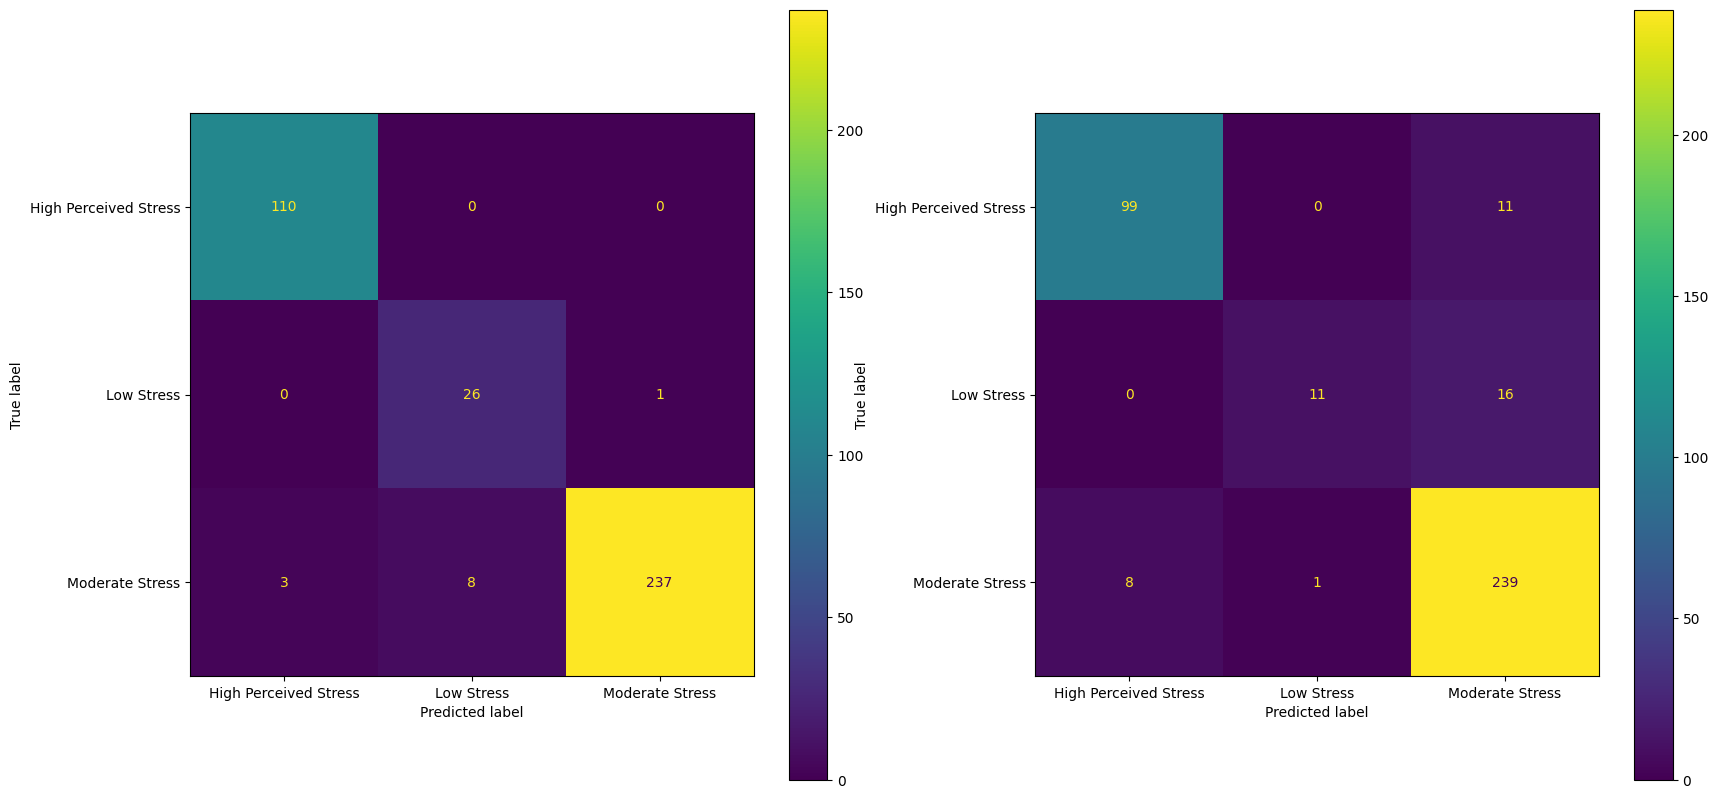

In [29]:
# confusion matrix
fig, ax = plt.subplots(1,2,figsize=(20, 10))
ConfusionMatrixDisplay.from_estimator(stress_label_model_logreg, X_test, y_stress_label_test, ax=ax[0])
ConfusionMatrixDisplay.from_estimator(stress_label_model_rforest, X_test, y_stress_label_test, ax=ax[1])
plt.show()

In [30]:
#saving the best model to model directory
joblib.dump(stress_label_model_rforest, '../models/stress_label_model_rforest.pkl')

['../models/stress_label_model_rforest.pkl']

In [31]:
# depression label models
depression_label_model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

depression_label_model_rforest = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

depression_label_model_logreg.fit(X_train, y_depression_label_train)

depression_label_model_rforest.fit(X_train, y_depression_label_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5


In [32]:
# depression label model evaluation
y_depression_label_pred_logreg = depression_label_model_logreg.predict(X_test)
y_depression_label_pred_rforest = depression_label_model_rforest.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_depression_label_test, y_depression_label_pred_logreg))

print("\nRandom Forest:")
print(classification_report(y_depression_label_test, y_depression_label_pred_rforest))

Logistic Regression:
                              precision    recall  f1-score   support

             Mild Depression       0.99      0.94      0.96        78
          Minimal Depression       0.84      1.00      0.91        21
         Moderate Depression       0.97      0.97      0.97        87
Moderately Severe Depression       0.96      0.96      0.96        99
           Severe Depression       0.98      0.98      0.98       100

                    accuracy                           0.96       385
                   macro avg       0.95      0.97      0.96       385
                weighted avg       0.97      0.96      0.96       385


Random Forest:
                              precision    recall  f1-score   support

             Mild Depression       0.82      0.79      0.81        78
          Minimal Depression       0.79      0.71      0.75        21
         Moderate Depression       0.80      0.74      0.77        87
Moderately Severe Depression       0.77      0.90

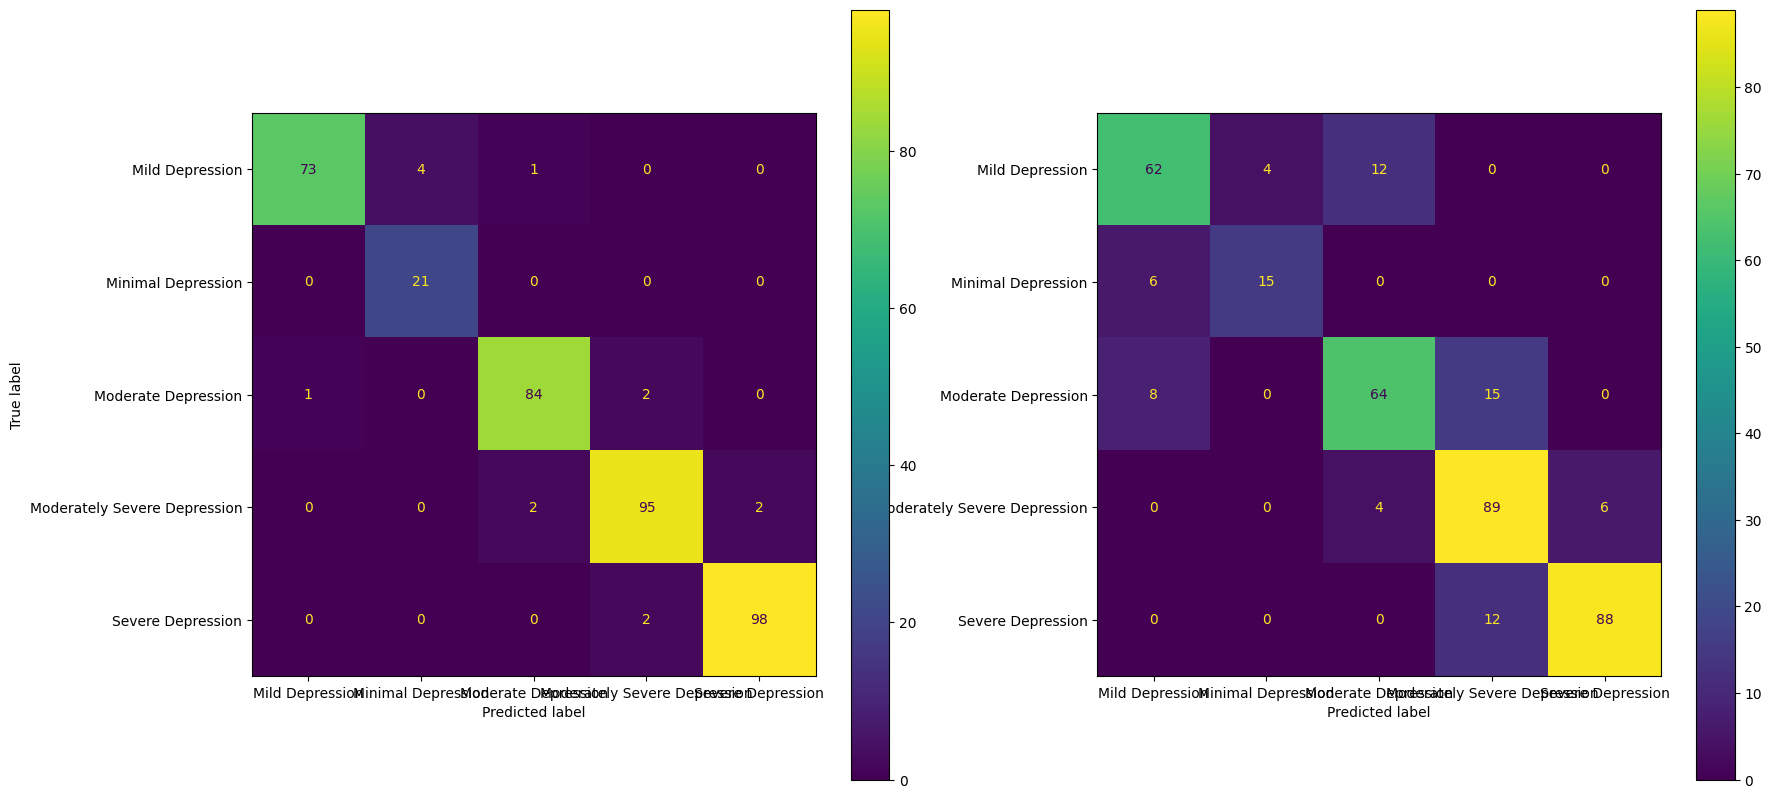

In [33]:
# confusion matrix
fig, ax = plt.subplots(1,2,figsize=(20, 10))
ConfusionMatrixDisplay.from_estimator(depression_label_model_logreg, X_test, y_depression_label_test, ax=ax[0])
ConfusionMatrixDisplay.from_estimator(depression_label_model_rforest, X_test, y_depression_label_test, ax=ax[1])
plt.show()

In [34]:
#saving the best model to model directory
joblib.dump(depression_label_model_rforest, '../models/depression_label_model_rforest.pkl')

['../models/depression_label_model_rforest.pkl']

In [35]:
# risk level models
risk_level_model_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

risk_level_model_rforest = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

risk_level_model_logreg.fit(X_train, y_risk_label_train)

risk_level_model_rforest.fit(X_train, y_risk_label_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,5


In [36]:
# risk level model evaluation
y_risk_label_pred_logreg = risk_level_model_logreg.predict(X_test)
y_risk_label_pred_rforest = risk_level_model_rforest.predict(X_test)

print("Logistic Regression:")
print(classification_report(y_risk_label_test, y_risk_label_pred_logreg))

print("\nRandom Forest:")
print(classification_report(y_risk_label_test, y_risk_label_pred_rforest))

Logistic Regression:
               precision    recall  f1-score   support

    High Risk       1.00      0.99      1.00       199
     Low Risk       0.81      1.00      0.89        21
Moderate Risk       0.99      0.97      0.98       165

     accuracy                           0.98       385
    macro avg       0.93      0.99      0.96       385
 weighted avg       0.99      0.98      0.99       385


Random Forest:
               precision    recall  f1-score   support

    High Risk       0.95      0.98      0.96       199
     Low Risk       0.87      0.62      0.72        21
Moderate Risk       0.93      0.92      0.92       165

     accuracy                           0.94       385
    macro avg       0.91      0.84      0.87       385
 weighted avg       0.93      0.94      0.93       385



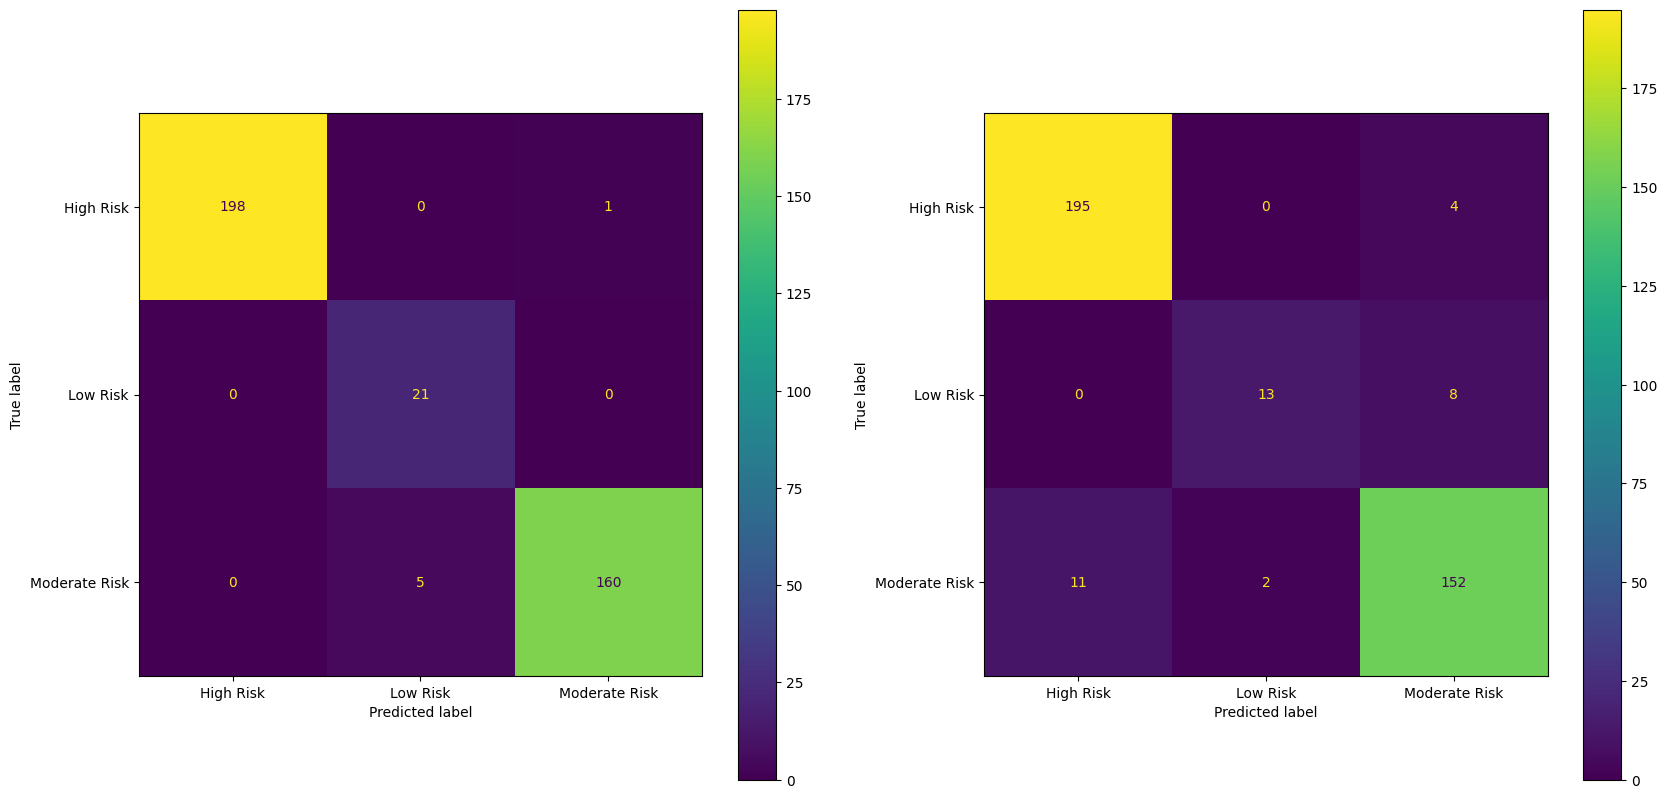

In [37]:
# confusion matrix
fig, ax = plt.subplots(1,2,figsize=(20, 10))
ConfusionMatrixDisplay.from_estimator(risk_level_model_logreg, X_test, y_risk_label_test, ax=ax[0])
ConfusionMatrixDisplay.from_estimator(risk_level_model_rforest, X_test, y_risk_label_test, ax=ax[1])
plt.show()

In [38]:
#saving the best model to model directory
joblib.dump(risk_level_model_rforest, '../models/risk_level_model_rforest.pkl')

['../models/risk_level_model_rforest.pkl']

## SHAP analysis

In [41]:
# --- paths ---
shap_bundle_path = "../models/risk_level_shap_explainer_bundle.pkl"

# --- use the trained risk RF model inside the pipeline ---
risk_rf_model = risk_level_model_rforest.named_steps["regressor"]

# Make class names explicit and robust
class_names = list(risk_rf_model.classes_)

# Build a representative background sample for SHAP
background = X_train_scaled[:100] if len(X_train_scaled) > 100 else X_train_scaled

# Tree SHAP explainer for the trained random forest
risk_explainer = shap.TreeExplainer(risk_rf_model, data=background)

# --- bundle everything needed for later explanations ---
shap_bundle = {
    "model": risk_rf_model,
    "scaler": risk_level_model_rforest.named_steps["scaler"],
    "feature_cols": feature_cols,
    "class_names": class_names,
    "background": background,
    "explainer": risk_explainer
}

joblib.dump(shap_bundle, shap_bundle_path)
print(f"Saved SHAP explainability bundle to: {shap_bundle_path}")

Saved SHAP explainability bundle to: ../models/risk_level_shap_explainer_bundle.pkl


In [42]:
def explain_risk_prediction(sample_df, bundle_path=shap_bundle_path, top_n=10):
    bundle = joblib.load(bundle_path)
    model = bundle["model"]
    scaler = bundle["scaler"]
    feature_cols = bundle["feature_cols"]
    class_names = bundle["class_names"]
    explainer = bundle["explainer"]

    # Scale input
    sample_scaled = scaler.transform(sample_df[feature_cols])
    sample_scaled_df = pd.DataFrame(sample_scaled, columns=feature_cols, index=sample_df.index)

    # Predict class and probabilities
    pred = model.predict(sample_scaled_df)[0]
    pred_proba = model.predict_proba(sample_scaled_df)[0]

    # SHAP values for this sample
    shap_values = explainer.shap_values(sample_scaled_df)

    # Get predicted class index
    if isinstance(pred, str):
        pred_class_idx = class_names.index(pred)
    else:
        pred_class_idx = int(pred)

    # Extract SHAP values only for the predicted class
    if isinstance(shap_values, np.ndarray):
        # Expected shape: (1, n_features, n_classes)
        pred_shap = shap_values[0, :, pred_class_idx]
    else:
        # Expected shape: list of arrays, one per class
        pred_shap = shap_values[pred_class_idx][0]

    # Top contributing features by absolute SHAP value
    top_idx = np.argsort(np.abs(pred_shap))[::-1][:top_n]
    top_features = pd.DataFrame({
        "feature": np.array(feature_cols)[top_idx],
        "shap_value": pred_shap[top_idx],
        "abs_shap_value": np.abs(pred_shap[top_idx])
    }).sort_values("abs_shap_value", ascending=False)

    print("Predicted class:", pred)
    print("Class probabilities:")
    for c, p in zip(class_names, pred_proba):
        print(f"  {c}: {p:.4f}")

    print(f"\nTop {top_n} contributing features for predicted class '{pred}':")
    print(top_features.to_string(index=False))

    # Waterfall explanation for predicted class only
    exp = shap.Explanation(
        values=pred_shap,
        base_values=explainer.expected_value[pred_class_idx],
        data=sample_scaled_df.iloc[0].values,
        feature_names=feature_cols
    )

    shap.plots.waterfall(exp, max_display=top_n)

    return pred, pred_proba, top_features, exp

Predicted class: High Risk
Class probabilities:
  High Risk: 0.9856
  Low Risk: 0.0000
  Moderate Risk: 0.0144

Top 10 contributing features for predicted class 'High Risk':
         feature  shap_value  abs_shap_value
     D2_Hopeless    0.060789        0.060789
        D4_Tired    0.060160        0.060160
 D3_SleepTrouble    0.046433        0.046433
  D8_Psychomotor    0.046372        0.046372
      D6_Failure    0.044700        0.044700
     D5_Appetite    0.041245        0.041245
D7_Concentration    0.041012        0.041012
 A5_TooMuchWorry    0.018626        0.018626
     A6_Restless   -0.018043        0.018043
    S10_PilingUp    0.014401        0.014401


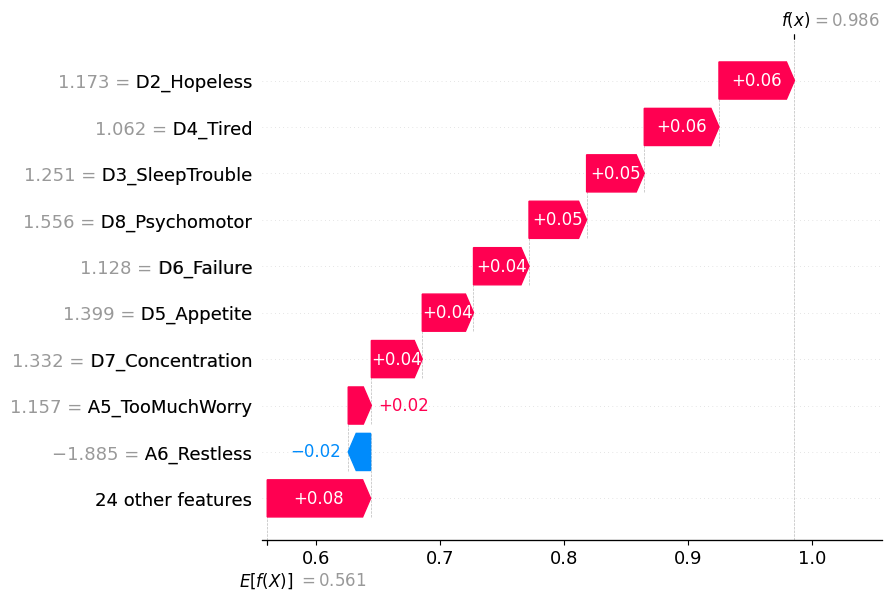

In [46]:
sample_221 = df.iloc[[221]]
result = explain_risk_prediction(sample_221)

# Safer, long-term access if you update the function to return a dict
pred = result[0]
pred_proba = result[1]
shap_values = result[2]